In [2]:
!pip install -q pennylane scikit-learn pandas matplotlib


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.random.seed(42); pnp.random.seed(42)
BASE = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/"
cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]
train = pd.read_csv(BASE + "KDDTrain%2B.txt", names=cols)
test  = pd.read_csv(BASE + "KDDTest%2B.txt",  names=cols)
print(train.shape, test.shape)

for d in (train, test):
    d["y"] = (d["label"] != "normal").astype(int)   # 0 = normal, 1 = attack
    d.drop(columns=["label", "difficulty"], inplace=True)

(125973, 43) (22544, 43)


In [4]:
N_TRAIN, N_TEST = 1000, 500      # simulator is slow, so we subsample
N_QUBITS, N_LAYERS, EPOCHS, BATCH = 8, 3, 20, 50

full = pd.get_dummies(pd.concat([train, test]), columns=["protocol_type","service","flag"])
tr, te = full.iloc[:len(train)], full.iloc[len(train):]
Xtr, ytr = tr.drop(columns="y").values.astype(float), tr["y"].values
Xte, yte = te.drop(columns="y").values.astype(float), te["y"].values

def sample(X, y, n):
    idx = []
    for c in (0, 1):
        idx += list(np.random.choice(np.where(y == c)[0], n // 2, replace=False))
    idx = np.random.permutation(idx)
    return X[idx], y[idx]

Xtr, ytr = sample(Xtr, ytr, N_TRAIN)
Xte, yte = sample(Xte, yte, N_TEST)

sc  = StandardScaler().fit(Xtr);                         Xtr, Xte = sc.transform(Xtr),  sc.transform(Xte)
sel = SelectKBest(mutual_info_classif, k=20).fit(Xtr, ytr); Xtr, Xte = sel.transform(Xtr), sel.transform(Xte)
pca = PCA(n_components=N_QUBITS).fit(Xtr);               Xtr, Xte = pca.transform(Xtr), pca.transform(Xte)
mm  = MinMaxScaler((0, np.pi)).fit(Xtr);                 Xtr, Xte = mm.transform(Xtr),  np.clip(mm.transform(Xte), 0, np.pi)
print("Quantum input shape:", Xtr.shape)

Quantum input shape: (1000, 8)


Epoch 1/20  loss=0.5277
Epoch 2/20  loss=0.3367
Epoch 3/20  loss=0.3240
Epoch 4/20  loss=0.3150
Epoch 5/20  loss=0.3190
Epoch 6/20  loss=0.3188
Epoch 7/20  loss=0.3134
Epoch 8/20  loss=0.3182
Epoch 9/20  loss=0.3154
Epoch 10/20  loss=0.3207
Epoch 11/20  loss=0.3147
Epoch 12/20  loss=0.3143
Epoch 13/20  loss=0.3171
Epoch 14/20  loss=0.3141
Epoch 15/20  loss=0.3157
Epoch 16/20  loss=0.3124
Epoch 17/20  loss=0.3136
Epoch 18/20  loss=0.3153
Epoch 19/20  loss=0.3136
Epoch 20/20  loss=0.3116


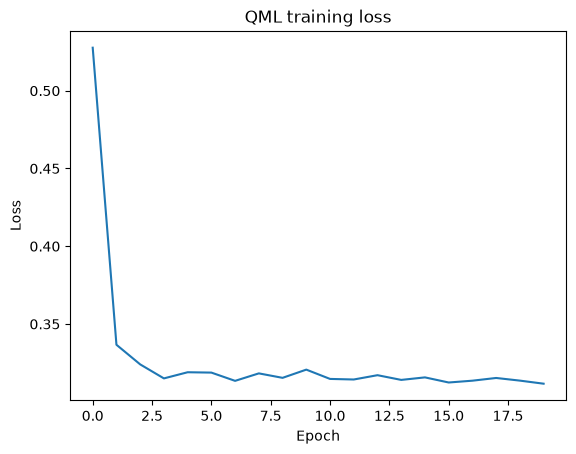

In [5]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="autograd", diff_method="backprop")
def circuit(x, w):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")   # quantum encoding
    qml.StronglyEntanglingLayers(w, wires=range(N_QUBITS))       # trainable layers
    return qml.expval(qml.PauliZ(0))                             # class score in [-1, 1]

def cost(w, b, x, y):
    return pnp.mean((circuit(x, w) + b - y) ** 2)

w = pnp.array(np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 3)), requires_grad=True)
b = pnp.array(0.0, requires_grad=True)
opt = qml.AdamOptimizer(0.1)
ys = 2 * ytr - 1     # labels to {-1, +1}
losses = []

t0 = time.time()
for ep in range(EPOCHS):
    perm = np.random.permutation(len(Xtr)); tot = 0; nb = 0
    for i in range(0, len(perm), BATCH):
        bi = perm[i:i+BATCH]
        xb = pnp.array(Xtr[bi], requires_grad=False)
        yb = pnp.array(ys[bi],  requires_grad=False)
        (w, b), c = opt.step_and_cost(lambda w, b: cost(w, b, xb, yb), w, b)
        tot += c; nb += 1
    losses.append(tot / nb)
    print(f"Epoch {ep+1}/{EPOCHS}  loss={losses[-1]:.4f}")
q_train_time = time.time() - t0

plt.plot(losses); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("QML training loss"); plt.show()

,Model,Accuracy,Precision,Recall,F1,FPR,Time_s
0,Hybrid QML (VQC),0.798,0.9515,0.628,0.7566,0.032,48.5254
1,SVM (RBF),0.760,0.8869,0.596,0.7129,0.076,0.0098
2,Random Forest,0.790,0.8919,0.660,0.7586,0.080,0.1964
3,Logistic Regression,0.774,0.8663,0.648,0.7414,0.100,0.0296


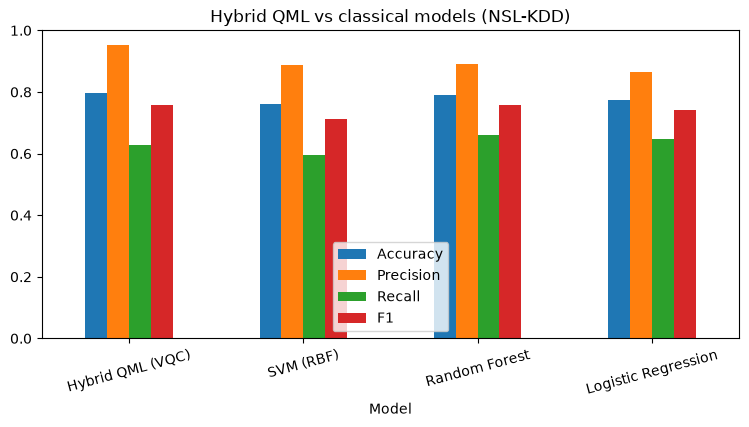

In [6]:
def metrics(name, yt, yp, t):
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    return dict(Model=name, Accuracy=accuracy_score(yt, yp), Precision=precision_score(yt, yp),
                Recall=recall_score(yt, yp), F1=f1_score(yt, yp), FPR=fp/(fp+tn), Time_s=t)

rows = []
t = time.time()
pq = (np.array(circuit(pnp.array(Xte), w)) + float(b) > 0).astype(int)
rows.append(metrics("Hybrid QML (VQC)", yte, pq, q_train_time + time.time() - t))

for name, m in [("SVM (RBF)", SVC()),
                ("Random Forest", RandomForestClassifier(100, random_state=42)),
                ("Logistic Regression", LogisticRegression(max_iter=1000))]:
    t = time.time(); m.fit(Xtr, ytr); p = m.predict(Xte)
    rows.append(metrics(name, yte, p, time.time() - t))

results = pd.DataFrame(rows).round(4)
display(results)

results.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar", figsize=(9,4), ylim=(0,1))
plt.title("Hybrid QML vs classical models (NSL-KDD)"); plt.xticks(rotation=15); plt.show()

(<Figure size 500x900 with 1 Axes>, <Axes: >)


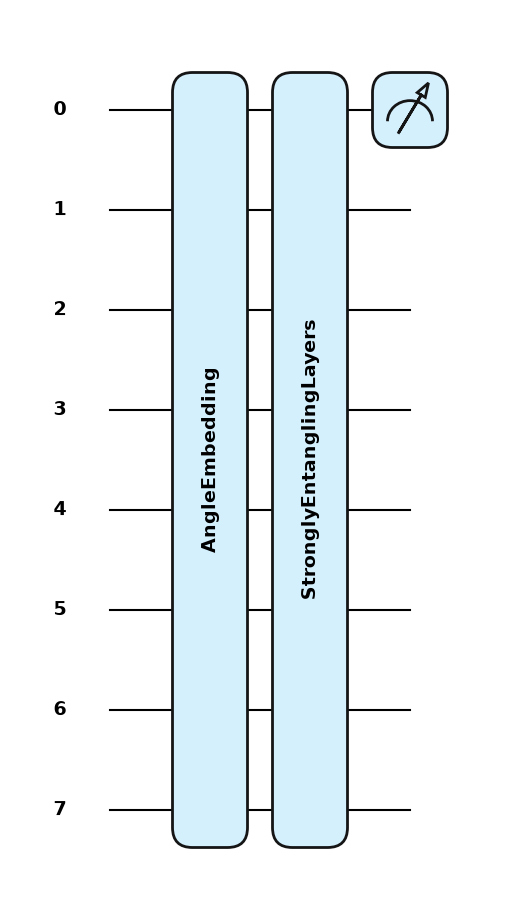

In [7]:
qml.drawer.use_style("pennylane")
print(qml.draw_mpl(circuit)(Xte[0], w))